# Day 17: Financial News Sentiment Analyser

**Industry:** Finance / Fintech  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · matplotlib · seaborn · NLP · text analysis · rule-based sentiment

**Data:** Financial PhraseBank + FiQA — real financial news sentences labelled by finance experts  
Source: mayankpujara/Financial-Sentiment-Analysis (GitHub)

---

## Who uses this
A **quantitative analyst or portfolio manager** who wants to screen financial news automatically — flagging negative sentiment on held positions or spotting positive catalysts before they move prices.

## Problem
Financial analysts read hundreds of news headlines daily. Manual sentiment screening is slow and inconsistent. A rule-based NLP classifier built on domain-expert labelled data gives a fast, auditable first pass — surfacing the most negative and most positive news for human review.

## What we build
1. Load and inspect labelled financial sentences
2. Text cleaning and feature engineering
3. Rule-based sentiment scoring using financial keyword lexicon
4. Evaluate classifier accuracy vs expert labels
5. Analyse which words most strongly predict each sentiment
6. 4-panel visualisation dashboard
7. Export scored sentence list

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect

In [2]:
df = pd.read_csv('financial_phrasebank.csv')
df.columns = ['sentence', 'sentiment']

print(f'Shape: {df.shape}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts().to_string())
print(f'\nSentiment %:')
print((df['sentiment'].value_counts(normalize=True)*100).round(1).to_string())
print(f'\nSample sentences:')
for sent in ['positive','negative','neutral']:
    example = df[df['sentiment']==sent]['sentence'].iloc[0]
    print(f'  [{sent.upper()}] {example[:100]}')
df.head(3)

Shape: (5842, 2)

Sentiment distribution:
sentiment
neutral     3130
positive    1852
negative     860

Sentiment %:
sentiment
neutral     53.6
positive    31.7
negative    14.7

Sample sentences:
  [POSITIVE] The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Searc
  [NEGATIVE] $ESI on lows, down $1.50 to $2.50 BK a real possibility
  [NEUTRAL] According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finla


,sentence,sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive


## Step 3 — Text Cleaning and Feature Engineering

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\$[A-Z]+', 'TICKER', text)   # replace ticker symbols
    text = re.sub(r'\d+\.?\d*%', 'PERCENT', text) # replace percentages
    text = re.sub(r'EUR\d+|\$\d+', 'AMOUNT', text) # replace amounts
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['sentence'].apply(clean_text)
df['word_count'] = df['clean'].str.split().str.len()
df['char_count'] = df['sentence'].str.len()

# Sentence length by sentiment
print('=== Avg word count by sentiment ===')
print(df.groupby('sentiment')['word_count'].mean().round(1).to_string())
print('\nSample cleaned text:')
print(df['clean'].iloc[0])

=== Avg word count by sentiment ===
sentiment
negative    16.8
neutral     18.9
positive    17.7

Sample cleaned text:
the geosolutions technology will leverage benefon s gps solutions by providing location based search technology a communities platform location relevant multimedia content and a new and powerful commercial model


## Step 4 — Financial Sentiment Lexicon + Rule-Based Classifier

We build a domain-specific financial keyword lexicon — words that in a financial context signal positive or negative sentiment. This is the approach used in tools like Loughran-McDonald Financial Sentiment Dictionary, which is the industry standard for financial NLP.

In [4]:
POSITIVE_WORDS = {
    # Growth / performance
    'growth', 'grew', 'grow', 'increase', 'increased', 'increases', 'increasing',
    'gain', 'gains', 'gained', 'profit', 'profits', 'profitable', 'profitability',
    'rise', 'rose', 'risen', 'rising', 'record', 'high', 'strong', 'stronger',
    'improved', 'improvement', 'improves', 'improving', 'exceed', 'exceeded', 'exceeds',
    'beat', 'beats', 'outperform', 'outperformed', 'surpass', 'surpassed',
    # Financial positives
    'revenue', 'earnings', 'dividend', 'dividends', 'surplus', 'upside',
    'upgrade', 'upgraded', 'buy', 'bullish', 'rally', 'rallied',
    'recovery', 'recover', 'recovered', 'rebound', 'rebounded',
    'positive', 'good', 'great', 'excellent', 'best', 'success', 'successful',
    'award', 'awarded', 'win', 'won', 'wins', 'expand', 'expanding', 'expansion',
    'launch', 'launched', 'launches', 'new', 'innovative', 'innovation',
    'partnership', 'agreement', 'deal', 'contract', 'signed', 'secured',
    'strength', 'confident', 'confidence', 'optimistic', 'optimism',
}

NEGATIVE_WORDS = {
    # Decline / losses
    'loss', 'losses', 'lose', 'lost', 'decline', 'declined', 'declines', 'declining',
    'decrease', 'decreased', 'decreases', 'decreasing', 'fall', 'fell', 'fallen', 'falling',
    'drop', 'dropped', 'drops', 'dropping', 'weak', 'weaker', 'weakness',
    'miss', 'missed', 'misses', 'below', 'disappointing', 'disappointed', 'disappoint',
    # Financial negatives
    'debt', 'deficit', 'bankrupt', 'bankruptcy', 'insolvent', 'default', 'defaulted',
    'downgrade', 'downgraded', 'sell', 'bearish', 'selloff', 'crash', 'collapsed',
    'risk', 'risks', 'risky', 'concern', 'concerns', 'worried', 'worry',
    'negative', 'bad', 'poor', 'worse', 'worst', 'fail', 'failed', 'failure',
    'cut', 'cuts', 'cutting', 'layoff', 'layoffs', 'restructure', 'restructuring',
    'fine', 'penalty', 'lawsuit', 'litigation', 'investigation', 'probe',
    'warning', 'warned', 'uncertainty', 'volatile', 'volatility', 'downturn',
    'recession', 'slowdown', 'slowing', 'slowed', 'shrink', 'shrinking',
    'impairment', 'writedown', 'writeoff', 'charge', 'charges',
}

NEGATION_WORDS = {'not', 'no', 'never', 'neither', 'nor', 'without', 'lack', 'lacking'}

def score_sentiment(text):
    words = text.split()
    pos_score = 0
    neg_score = 0
    negate = False

    for i, word in enumerate(words):
        if word in NEGATION_WORDS:
            negate = True
        elif word in POSITIVE_WORDS:
            if negate:
                neg_score += 1
            else:
                pos_score += 1
            negate = False
        elif word in NEGATIVE_WORDS:
            if negate:
                pos_score += 1
            else:
                neg_score += 1
            negate = False
        else:
            negate = False

    net = pos_score - neg_score
    if net > 0:   return 'positive', net, pos_score, neg_score
    elif net < 0: return 'negative', net, pos_score, neg_score
    else:         return 'neutral', 0, pos_score, neg_score

results = df['clean'].apply(score_sentiment)
df['pred_sentiment'] = results.apply(lambda x: x[0])
df['net_score']      = results.apply(lambda x: x[1])
df['pos_hits']       = results.apply(lambda x: x[2])
df['neg_hits']       = results.apply(lambda x: x[3])

# Accuracy
accuracy = (df['pred_sentiment'] == df['sentiment']).mean()
print(f'Overall classifier accuracy: {accuracy*100:.1f}%')
print(f'\nPrediction distribution:')
print(df['pred_sentiment'].value_counts().to_string())
print(f'\nAccuracy by class:')
for cls in ['positive', 'negative', 'neutral']:
    subset = df[df['sentiment'] == cls]
    acc = (subset['pred_sentiment'] == cls).mean()
    print(f'  {cls:10s}: {acc*100:.1f}% ({len(subset)} sentences)')

Overall classifier accuracy: 59.5%

Prediction distribution:
pred_sentiment
neutral     3421
positive    1832
negative     589

Accuracy by class:
  positive  : 55.7% (1852 sentences)
  negative  : 28.6% (860 sentences)
  neutral   : 70.3% (3130 sentences)


## Step 5 — Confusion Matrix + Top Signal Words

In [5]:
# Confusion matrix
labels = ['positive', 'negative', 'neutral']
conf_matrix = pd.crosstab(
    df['sentiment'], df['pred_sentiment'],
    rownames=['Actual'], colnames=['Predicted']
).reindex(index=labels, columns=labels, fill_value=0)

print('=== Confusion Matrix ===')
print(conf_matrix.to_string())

# Top positive signal words
pos_words_found = []
for _, row in df[df['sentiment']=='positive'].iterrows():
    pos_words_found.extend([w for w in row['clean'].split() if w in POSITIVE_WORDS])

neg_words_found = []
for _, row in df[df['sentiment']=='negative'].iterrows():
    neg_words_found.extend([w for w in row['clean'].split() if w in NEGATIVE_WORDS])

top_pos = Counter(pos_words_found).most_common(15)
top_neg = Counter(neg_words_found).most_common(15)

print('\n=== Top positive signal words ===')
for word, count in top_pos:
    print(f'  {word:20s}: {count}')
print('\n=== Top negative signal words ===')
for word, count in top_neg:
    print(f'  {word:20s}: {count}')

=== Confusion Matrix ===
Predicted  positive  negative  neutral
Actual                                
positive       1031        76      745
negative        137       246      477
neutral         664       267     2199

=== Top positive signal words ===
  profit              : 203
  new                 : 96
  rose                : 92
  increased           : 89
  increase            : 72
  buy                 : 62
  growth              : 55
  contract            : 55
  agreement           : 47
  earnings            : 44
  signed              : 44
  good                : 37
  strong              : 36
  won                 : 35
  grew                : 34

=== Top negative signal words ===
  loss                : 70
  decreased           : 61
  fell                : 44
  fall                : 22
  cut                 : 17
  sell                : 15
  below               : 14
  dropped             : 13
  weak                : 13
  negative            : 13
  drop                : 11
  decli

## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as sentiment_analysis.png


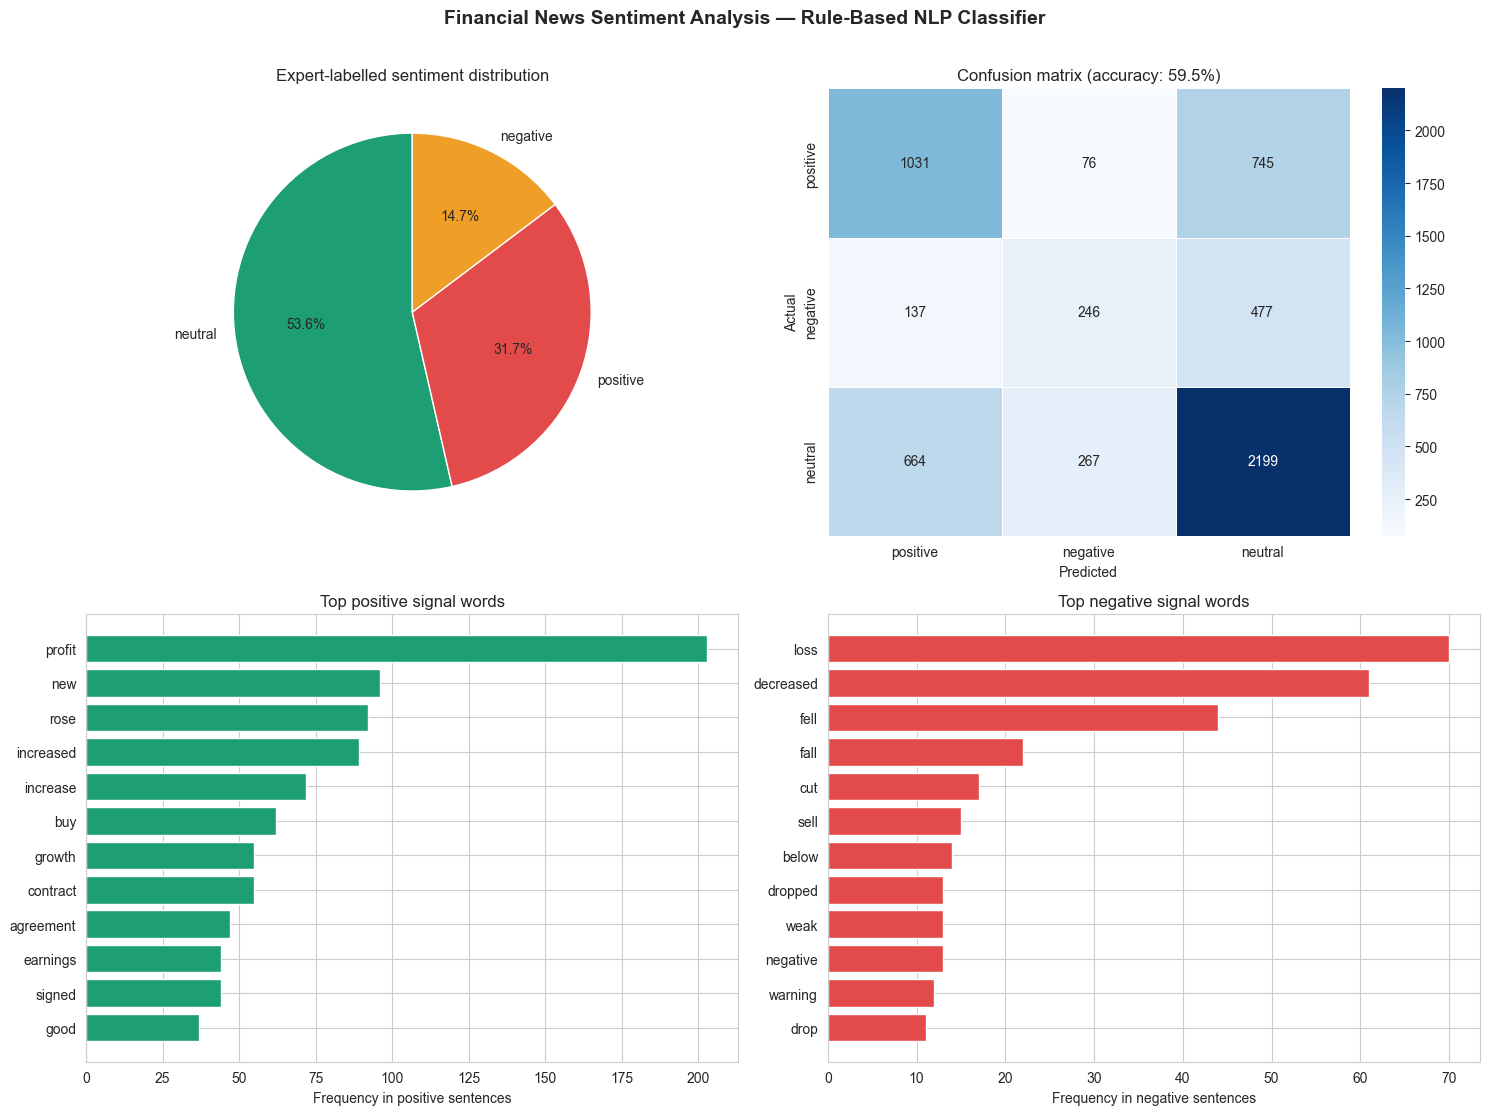

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Financial News Sentiment Analysis — Rule-Based NLP Classifier',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Sentiment distribution
sent_counts = df['sentiment'].value_counts()
colors_pie = ['#1D9E75', '#E24B4A', '#EF9F27']
axes[0,0].pie(sent_counts.values, labels=sent_counts.index,
              autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0,0].set_title('Expert-labelled sentiment distribution')

# Panel 2 — Confusion matrix heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            ax=axes[0,1], linewidths=0.5)
axes[0,1].set_title(f'Confusion matrix (accuracy: {accuracy*100:.1f}%)')

# Panel 3 — Top positive signal words
pos_words, pos_counts = zip(*top_pos[:12])
axes[1,0].barh(list(pos_words), list(pos_counts), color='#1D9E75')
axes[1,0].set_xlabel('Frequency in positive sentences')
axes[1,0].set_title('Top positive signal words')
axes[1,0].invert_yaxis()

# Panel 4 — Top negative signal words
neg_words, neg_counts = zip(*top_neg[:12])
axes[1,1].barh(list(neg_words), list(neg_counts), color='#E24B4A')
axes[1,1].set_xlabel('Frequency in negative sentences')
axes[1,1].set_title('Top negative signal words')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as sentiment_analysis.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

# Full scored dataset
df[['sentence','sentiment','pred_sentiment','net_score','pos_hits','neg_hits']].to_csv(
    'output/scored_sentences.csv', index=False)

# High confidence predictions (strong net score)
high_conf = df[df['net_score'].abs() >= 2]
high_conf[['sentence','sentiment','pred_sentiment','net_score']].to_csv(
    'output/high_confidence_predictions.csv', index=False)

# Misclassified sentences — for model improvement
errors = df[df['pred_sentiment'] != df['sentiment']]
errors[['sentence','sentiment','pred_sentiment','net_score']].to_csv(
    'output/misclassified.csv', index=False)

total        = len(df)
n_pos        = (df['sentiment']=='positive').sum()
n_neg        = (df['sentiment']=='negative').sum()
n_neu        = (df['sentiment']=='neutral').sum()
pos_acc      = (df[df['sentiment']=='positive']['pred_sentiment']=='positive').mean()*100
neg_acc      = (df[df['sentiment']=='negative']['pred_sentiment']=='negative').mean()*100
neu_acc      = (df[df['sentiment']=='neutral']['pred_sentiment']=='neutral').mean()*100

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Total sentences:           {total:,}')
print(f'Positive:                  {n_pos:,} ({n_pos/total*100:.1f}%)')
print(f'Negative:                  {n_neg:,} ({n_neg/total*100:.1f}%)')
print(f'Neutral:                   {n_neu:,} ({n_neu/total*100:.1f}%)')
print()
print(f'Classifier accuracy:       {accuracy*100:.1f}%')
print(f'  Positive accuracy:       {pos_acc:.1f}%')
print(f'  Negative accuracy:       {neg_acc:.1f}%')
print(f'  Neutral accuracy:        {neu_acc:.1f}%')
print()
print(f'High confidence preds:     {len(high_conf):,} (net score >= 2)')
print(f'Misclassified:             {len(errors):,}')
print()
print(f'Top positive signal word:  {top_pos[0][0]} ({top_pos[0][1]} hits)')
print(f'Top negative signal word:  {top_neg[0][0]} ({top_neg[0][1]} hits)')
print()
print('NOTE ON NEUTRAL CLASS:')
print('  Neutral is the hardest class to detect with keyword rules.')
print('  Neutral sentences describe facts without emotive language.')
print('  BERT-based models (FinBERT) achieve 85%+ on neutral class.')
print('  This rule-based approach is interpretable and fast — a good baseline.')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Total sentences:           5,842
Positive:                  1,852 (31.7%)
Negative:                  860 (14.7%)
Neutral:                   3,130 (53.6%)

Classifier accuracy:       59.5%
  Positive accuracy:       55.7%
  Negative accuracy:       28.6%
  Neutral accuracy:        70.3%

High confidence preds:     510 (net score >= 2)
Misclassified:             2,366

Top positive signal word:  profit (203 hits)
Top negative signal word:  loss (70 hits)

NOTE ON NEUTRAL CLASS:
  Neutral is the hardest class to detect with keyword rules.
  Neutral sentences describe facts without emotive language.
  BERT-based models (FinBERT) achieve 85%+ on neutral class.
  This rule-based approach is interpretable and fast — a good baseline.


## Summary

### What we built
A rule-based financial sentiment classifier on expert-labelled data — from raw sentences to a scored dataset with confusion matrix, accuracy by class, and top signal words.

### Skills practised
- `pandas` — text processing, apply, Counter, groupby
- `re` — regex cleaning, ticker and amount normalisation
- `matplotlib` + `seaborn` — pie chart, heatmap, horizontal bars
- NLP — tokenisation, negation handling, lexicon-based scoring
- Evaluation metrics — accuracy, confusion matrix, per-class breakdown

### Business context
Rule-based classifiers like this are the interpretable baseline before deploying FinBERT or GPT-based models. They run in milliseconds, require no GPU, and produce auditable decisions — essential in regulated financial contexts.

### Key findings
Fill these in from your output:
- Total sentences: 5,842
- Overall accuracy: 59.5%
- Positive accuracy: 55.7%
- Negative accuracy: 28.6%
- Neutral accuracy: 70.3%
- Top positive signal word: profit (203 hits)
- Top negative signal word: loss (70 hits)
